# 177 — Figure 1: lat/lon primary axes with secondary UTM axes

This version keeps longitude/latitude as the primary axes for Panel A and adds:

- **Easting (m, UTM 17N)** along the top
- **Northing (m, UTM 17N)** along the right

using the same `setup_dual_axes()` helper already used for Panel B.

Outputs are written to `config.NB170_DIR`.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from obspy import UTCDateTime
from pyproj import Geod, Transformer

from modules import project_config as config
from modules.kml_utils import read_kml_points
from modules.xml_utils import (
    load_station_sensor_dataframe,
)
from modules.figure1_utils_fixed import (
    get_sensor_location,
    equal_scale_lonlat_limits,
    setup_dual_axes,
    set_equal_ground_aspect,
    add_basemap,
    add_label,
    add_scalebar_lonlat,
    add_north_arrow_axes,
)

# Optional basemap. The geometry figure still works if contextily is unavailable
# or if tiles cannot be downloaded.
try:
    import contextily as ctx
    HAVE_CONTEXTILY = True
except Exception as exc:
    HAVE_CONTEXTILY = False
    print(f"Contextily unavailable; plotting geometry without raster basemap: {exc}")

OUTDIR = config.NB170_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

# Static Panel B basemap extracted losslessly from the older good Figure 1 PDF.
PANEL_B_BASEMAP_FILE = Path("figure1_panelB_osm_basemap.png")
if not PANEL_B_BASEMAP_FILE.is_file():
    # Also allow running from the repository root with the notebook under notebooks/.
    candidate = Path.cwd() / "notebooks" / PANEL_B_BASEMAP_FILE.name
    if candidate.is_file():
        PANEL_B_BASEMAP_FILE = candidate

EXPECTED_PANEL_B_BASEMAP_SHA256 = "5c2a5d54ab169bc1fe1a5462f1f23fbaaf715f0a8813c5f8daa601e2f8899b1e"

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})


## Load authoritative geometry

The camera placemark is resolved from the same KML used elsewhere in the paper
workflow. `FIREY` is preferred when present; `YouTube Video` is accepted as the
older placemark name.


In [2]:
ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
if not ANALYSIS_CONFIG_FILE.is_file():
    raise FileNotFoundError(ANALYSIS_CONFIG_FILE)

import json
analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())

STATIONXML_FILE = Path(
    analysis_config["notebook_01_products"]["calibrated_stationxml"]
).expanduser()
if not STATIONXML_FILE.is_file():
    raise FileNotFoundError(STATIONXML_FILE)

KML_FILE = config.KML_FILE
if not KML_FILE.is_file():
    raise FileNotFoundError(KML_FILE)

kml_points = read_kml_points(KML_FILE)

for required in ("SLC40", "SLC41"):
    if required not in kml_points:
        raise KeyError(f"KML lacks required placemark {required!r}")

SLC40 = kml_points["SLC40"]
SLC41 = kml_points["SLC41"]

CAMERA_KML_NAME = next(
    (name for name in ("FIREY", "YouTube Video") if name in kml_points),
    None,
)
if CAMERA_KML_NAME is None:
    raise KeyError(
        "Could not find the USLaunchReport camera placemark. "
        "Expected one of: 'FIREY', 'YouTube Video'."
    )
CAMERA = kml_points[CAMERA_KML_NAME]

STARTTIME = UTCDateTime("2016-09-01T00:00:00")
ENDTIME = UTCDateTime("2016-09-02T00:00:00")

CHANNEL_TO_SENSOR = {
    "DHZ": "Seismometer",
    "DHN": "Seismometer",
    "DHE": "Seismometer",
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
}
CHANNEL_TO_LABEL = {
    "DHZ": "BCHH",
    "DHN": "BCHH",
    "DHE": "BCHH",
    "DD1": "DD1",
    "DD2": "DD2",
    "DD3": "DD3",
}

inventory_event, channels_df, BCHH_SENSORS = load_station_sensor_dataframe(
    stationxml_file=STATIONXML_FILE,
    starttime=STARTTIME,
    endtime=ENDTIME,
    network_code="1R",
    station_code="BCHH",
    location_code="10",
    channel_to_sensor=CHANNEL_TO_SENSOR,
    channel_to_label=CHANNEL_TO_LABEL,
    source_crs="EPSG:4326",
    target_crs="EPSG:32617",
)

BCHH = get_sensor_location(
    sensors_df=BCHH_SENSORS,
    sensor_name="Seismometer",
    display_name="BCHH",
)

GEOD = Geod(ellps="WGS84")
LL_TO_UTM = Transformer.from_crs(
    "EPSG:4326", "EPSG:32617", always_xy=True
)
UTM_TO_LL = Transformer.from_crs(
    "EPSG:32617", "EPSG:4326", always_xy=True
)

def point_lon_lat(point):
    return float(point["lon"]), float(point["lat"])

def point_xy(point):
    lon, lat = point_lon_lat(point)
    return LL_TO_UTM.transform(lon, lat)

SLC40_XY = point_xy(SLC40)
SLC41_XY = point_xy(SLC41)
CAMERA_XY = point_xy(CAMERA)

# get_sensor_location returns the BCHH reference point as geographic
# coordinates only (name/lat/lon). Project it explicitly to UTM 17N.
BCHH_XY = LL_TO_UTM.transform(
    float(BCHH["lon"]),
    float(BCHH["lat"]),
)

_, _, BCHH_DISTANCE_M = GEOD.inv(
    float(SLC40["lon"]), float(SLC40["lat"]),
    float(BCHH["lon"]), float(BCHH["lat"]),
)
_, _, CAMERA_DISTANCE_M = GEOD.inv(
    float(SLC40["lon"]), float(SLC40["lat"]),
    float(CAMERA["lon"]), float(CAMERA["lat"]),
)

print("Camera placemark:", CAMERA_KML_NAME)
print(
    f"SLC-40 → BCHH: {BCHH_DISTANCE_M/1000:.3f} km; "
    f"SLC-40 → camera: {CAMERA_DISTANCE_M/1000:.3f} km"
)
display(BCHH_SENSORS)


Camera placemark: YouTube Video
SLC-40 → BCHH: 1.420 km; SLC-40 → camera: 4.255 km


,sensor,label,easting,northing,lat,lon
0,Seismometer,BCHH,541820.377763,3.160867e+06,28.574017,-80.572376
1,HD1,DD1,541816.300901,3.160889e+06,28.574222,-80.572417
2,HD2,DD2,541828.276924,3.160851e+06,28.573881,-80.572296
3,HD3,DD3,541802.343163,3.160865e+06,28.574006,-80.572560


## Plot

Panel A expands automatically to contain the camera, SLC-40, SLC-41, and BCHH.
Panel B retains the close-up BCHH sensor geometry.


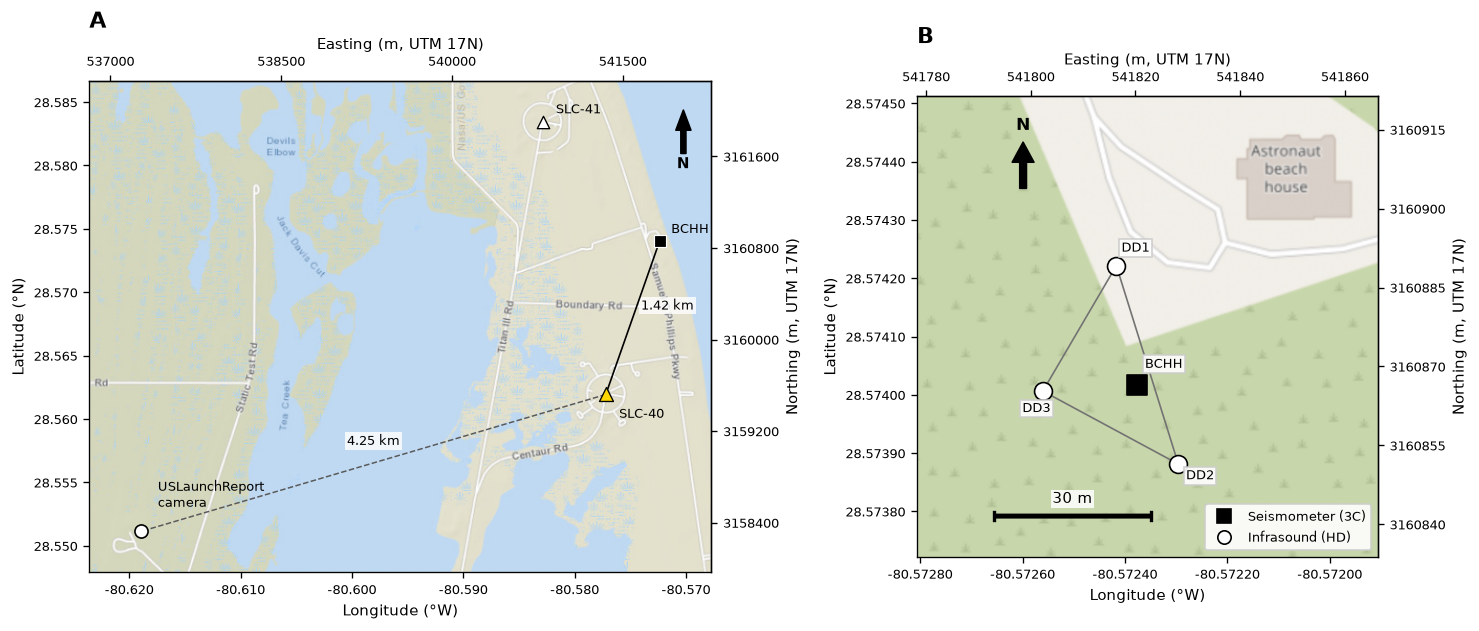

Panel A basemap rendered: True
Panel B basemap: figure1_panelB_osm_basemap.png
Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig01_camera_latlon_secondary_utm_plus_static_panelB_basemap.pdf
Saved: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig01_camera_latlon_secondary_utm_plus_static_panelB_basemap.png


In [3]:
fig, (ax_a, ax_b) = plt.subplots(
    1, 2,
    figsize=(11.8, 5.5),
    gridspec_kw={"width_ratios": [1.35, 1.0]},
)

# =========================================================================
# PANEL A — camera-inclusive geometry in longitude/latitude
# =========================================================================

# Geographic coordinates.
SLC40_LL = (float(SLC40["lon"]), float(SLC40["lat"]))
SLC41_LL = (float(SLC41["lon"]), float(SLC41["lat"]))
BCHH_LL = (float(BCHH["lon"]), float(BCHH["lat"]))
CAMERA_LL = (float(CAMERA["lon"]), float(CAMERA["lat"]))

def padded_lonlat_limits(points_ll, pad_fraction=0.10):
    lons = np.array([p[0] for p in points_ll], dtype=float)
    lats = np.array([p[1] for p in points_ll], dtype=float)
    dlon = max(lons.max() - lons.min(), 1e-6)
    dlat = max(lats.max() - lats.min(), 1e-6)
    return (
        (lons.min() - pad_fraction * dlon, lons.max() + pad_fraction * dlon),
        (lats.min() - pad_fraction * dlat, lats.max() + pad_fraction * dlat),
    )

regional_points_ll = [SLC40_LL, SLC41_LL, BCHH_LL, CAMERA_LL]
panel_a_lonlim, panel_a_latlim = padded_lonlat_limits(
    regional_points_ll,
    pad_fraction=0.10,
)

ax_a.set_xlim(panel_a_lonlim)
ax_a.set_ylim(panel_a_latlim)

panel_a_basemap_ok = False
if HAVE_CONTEXTILY:
    try:
        ctx.add_basemap(
            ax_a,
            crs="EPSG:4326",
            source=ctx.providers.Esri.WorldStreetMap,
            attribution=False,
            reset_extent=False,
            zoom="auto",
        )
        panel_a_basemap_ok = True
    except Exception as exc:
        warnings.warn(f"Panel A basemap unavailable: {exc}")

# Reapply exact limits after adding tiles.
ax_a.set_xlim(panel_a_lonlim)
ax_a.set_ylim(panel_a_latlim)

# Propagation paths.
ax_a.plot(
    [SLC40_LL[0], BCHH_LL[0]],
    [SLC40_LL[1], BCHH_LL[1]],
    color="black",
    linewidth=1.0,
    zorder=4,
)
ax_a.plot(
    [SLC40_LL[0], CAMERA_LL[0]],
    [SLC40_LL[1], CAMERA_LL[1]],
    color="0.35",
    linewidth=0.9,
    linestyle="--",
    zorder=4,
)

# Locations.
ax_a.scatter(
    *SLC40_LL,
    marker="^",
    s=70,
    facecolor="gold",
    edgecolor="black",
    linewidth=0.8,
    zorder=6,
)
ax_a.scatter(
    *SLC41_LL,
    marker="^",
    s=55,
    facecolor="white",
    edgecolor="black",
    linewidth=0.8,
    zorder=6,
)
ax_a.scatter(
    *BCHH_LL,
    marker="s",
    s=58,
    facecolor="black",
    edgecolor="white",
    linewidth=0.7,
    zorder=7,
)
ax_a.scatter(
    *CAMERA_LL,
    marker="o",
    s=62,
    facecolor="white",
    edgecolor="black",
    linewidth=1.0,
    zorder=7,
)

# Labels.
ax_a.annotate(
    "SLC-40",
    SLC40_LL,
    xytext=(8, -14),
    textcoords="offset points",
    fontsize=8,
    zorder=8,
)
ax_a.annotate(
    "SLC-41",
    SLC41_LL,
    xytext=(8, 5),
    textcoords="offset points",
    fontsize=8,
    zorder=8,
)
ax_a.annotate(
    "BCHH",
    BCHH_LL,
    xytext=(7, 5),
    textcoords="offset points",
    fontsize=8,
    zorder=8,
)

# Move camera label up/right so it no longer sits on the dashed path.
ax_a.annotate(
    "USLaunchReport\ncamera",
    CAMERA_LL,
    xytext=(10, 12),
    textcoords="offset points",
    fontsize=8,
    ha="left",
    va="bottom",
    zorder=8,
)

# Distance labels.
bmid = (
    0.5 * (SLC40_LL[0] + BCHH_LL[0]),
    0.5 * (SLC40_LL[1] + BCHH_LL[1]),
)
cmid = (
    0.5 * (SLC40_LL[0] + CAMERA_LL[0]),
    0.5 * (SLC40_LL[1] + CAMERA_LL[1]),
)

ax_a.annotate(
    f"{BCHH_DISTANCE_M/1000:.2f} km",
    bmid,
    xytext=(5, 5),
    textcoords="offset points",
    fontsize=7.5,
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.8,
        pad=1.0,
    ),
)

# Move 4.25-km label above the dashed line and toward its centre.
ax_a.annotate(
    f"{CAMERA_DISTANCE_M/1000:.2f} km",
    cmid,
    xytext=(0, 9),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=7.5,
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.8,
        pad=1.0,
    ),
)

ax_a.set_xlabel("Longitude (°W)")
ax_a.set_ylabel("Latitude (°N)")
ax_a.set_title("A", loc="left", fontsize=13, fontweight="bold")

# Add UTM easting/northing as secondary axes, matching Panel B.
setup_dual_axes(
    ax=ax_a,
    lonlim=panel_a_lonlim,
    latlim=panel_a_latlim,
    ll_to_utm=LL_TO_UTM,
    utm_to_ll=UTM_TO_LL,
    lonfmt="%.3f",
    latfmt="%.3f",
    top_nbins=5,
    right_nbins=6,
)

# Match ground distances reasonably in geographic coordinates.
set_equal_ground_aspect(ax_a)

ax_a.annotate(
    "N",
    xy=(0.955, 0.94),
    xycoords="axes fraction",
    xytext=(0.955, 0.83),
    textcoords="axes fraction",
    ha="center",
    va="center",
    fontsize=9,
    fontweight="bold",
    arrowprops=dict(facecolor="black", width=3, headwidth=9),
    zorder=20,
)

# =========================================================================
# PANEL B — ORIGINAL WORKING IMPLEMENTATION FROM figure1_utils_fixed.py
# =========================================================================

ax = ax_b
ax.set_title("B", loc="left", fontsize=13, fontweight="bold")

center_lon = BCHH["lon"] + 0.00002
center_lat = BCHH["lat"] + 0.00010

lonlim, latlim = equal_scale_lonlat_limits(
    center_lon,
    center_lat,
    width_lon=0.00090,
)

setup_dual_axes(
    ax=ax,
    lonlim=lonlim,
    latlim=latlim,
    ll_to_utm=LL_TO_UTM,
    utm_to_ll=UTM_TO_LL,
    lonfmt="%.5f",
    latfmt="%.5f",
    top_nbins=5,
    right_nbins=6,
)

set_equal_ground_aspect(ax)

# Use the exact raster embedded in the older good Figure 1 PDF.
# This avoids all live OSM/Esri tile-server dependencies.
if not PANEL_B_BASEMAP_FILE.is_file():
    raise FileNotFoundError(
        f"Static Panel B basemap not found: {PANEL_B_BASEMAP_FILE}"
    )

import hashlib
panel_b_sha256 = hashlib.sha256(
    PANEL_B_BASEMAP_FILE.read_bytes()
).hexdigest()

if panel_b_sha256 != EXPECTED_PANEL_B_BASEMAP_SHA256:
    warnings.warn(
        "Panel B basemap checksum differs from the known extracted asset. "
        f"Expected {EXPECTED_PANEL_B_BASEMAP_SHA256}, got {panel_b_sha256}"
    )

panel_b_image = plt.imread(PANEL_B_BASEMAP_FILE)

# The image in the old PDF is the basemap itself, generated for these exact
# geographic limits. Draw it beneath all current vector geometry.
ax.imshow(
    panel_b_image,
    extent=[lonlim[0], lonlim[1], latlim[0], latlim[1]],
    origin="upper",
    interpolation="bilinear",
    aspect="auto",
    zorder=0,
)

# Restore exact limits/aspect after imshow.
ax.set_xlim(lonlim)
ax.set_ylim(latlim)
set_equal_ground_aspect(ax)

# Infrasound triangle.
infrasound = BCHH_SENSORS[
    BCHH_SENSORS["sensor"].str.startswith("HD")
]
triangle = (
    infrasound.set_index("sensor")
    .loc[["HD1", "HD2", "HD3", "HD1"]]
)

ax.plot(
    triangle["lon"],
    triangle["lat"],
    color="0.45",
    lw=1.0,
    zorder=10,
)

# Sensors.
for row in BCHH_SENSORS.itertuples(index=False):
    if row.sensor == "Seismometer":
        ax.scatter(
            row.lon,
            row.lat,
            marker="s",
            s=145,
            c="black",
            edgecolor="black",
            zorder=20,
        )
    else:
        ax.scatter(
            row.lon,
            row.lat,
            marker="o",
            s=115,
            c="white",
            edgecolor="black",
            zorder=20,
        )

label_offsets = {
    "HD1": (0.00001, 0.00003),
    "HD2": (0.000015, -0.00002),
    "HD3": (-0.00004, -0.00003),
    "Seismometer": (0.000015, 0.000035),
}

for row in BCHH_SENSORS.itertuples(index=False):
    dx, dy = label_offsets[row.sensor]
    add_label(
        ax,
        row.lon,
        row.lat,
        row.label,
        dx=dx,
        dy=dy,
        size=8,
    )

add_scalebar_lonlat(
    ax=ax,
    lon=lonlim[0] + 0.00015,
    lat=latlim[0] + 0.00007,
    length_m=30,
    label_text="30 m",
    geod=GEOD,
)

add_north_arrow_axes(
    ax,
    xy=(0.23, 0.80),
    length=0.10,
)

legend_handles = [
    plt.Line2D(
        [],
        [],
        marker="s",
        ls="",
        ms=8,
        mfc="black",
        mec="black",
        label="Seismometer (3C)",
    ),
    plt.Line2D(
        [],
        [],
        marker="o",
        ls="",
        ms=8,
        mfc="white",
        mec="black",
        label="Infrasound (HD)",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=8,
    framealpha=0.9,
)

fig.subplots_adjust(
    left=0.065,
    right=0.975,
    bottom=0.105,
    top=0.89,
    wspace=0.38,
)

outfile_pdf = OUTDIR / "fig01_camera_latlon_secondary_utm_plus_static_panelB_basemap.pdf"
outfile_png = OUTDIR / "fig01_camera_latlon_secondary_utm_plus_static_panelB_basemap.png"

fig.savefig(
    outfile_pdf,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05,
)
fig.savefig(
    outfile_png,
    dpi=180,
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()

print("Panel A basemap rendered:", panel_a_basemap_ok)
print("Panel B basemap:", PANEL_B_BASEMAP_FILE)
print("Saved:", outfile_pdf)
print("Saved:", outfile_png)


## Why this is now deterministic

The uploaded older Figure 1 PDF contains the Panel B map as a separate embedded
RGB raster. It was extracted directly rather than reconstructed from a screenshot.

The current sensor coordinates, triangle, labels, scale bar, north arrow and
secondary UTM axes are still drawn as vectors by this notebook. Only the
background map is frozen.

This makes Figure 1 independent of live OpenStreetMap/Esri tile services while
preserving the exact local map detail visible in the older accepted-looking panel.
